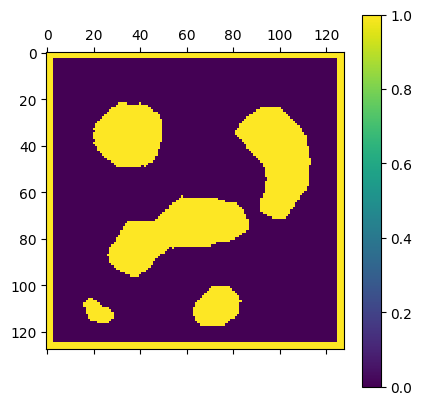

In [96]:
#Exercise_0
#loading Grid map environment frm given code.
#python code snip
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
# Load grid map
image = Image.open('map0.png').convert('L')
grid_map = np.array(image.getdata()).reshape(image.size[0], image.size[1])/255
# binarize the image
grid_map[grid_map > 0.5] = 1
grid_map[grid_map <= 0.5] = 0
# Invert colors to make 0 -> free and 1 -> occupied
grid_map = (grid_map * -1) + 1
# Show grid map
plt.matshow(grid_map)
plt.colorbar()
plt.show()

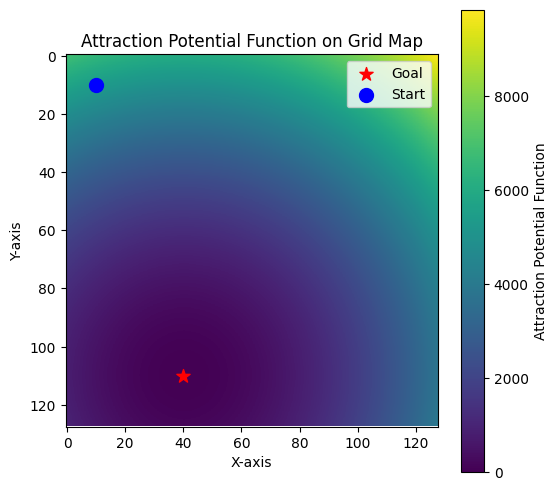

In [97]:
#Part 1
#Attraction function: Quadratic Potential Function
#Exercise 1:
def compute_attraction_potential(grid_map, start_position, goal_position):
    """
    To compute attraction potential field for a given grid map, start, and goal position.
    """
    height, width = grid_map.shape
    attraction_potential = np.zeros((height, width))
    scale=1 #attraction potential factor
    
    # To Calculate the attraction potential using Euclidean distance from each cell to the goal position
    for y in range(height):
        for x in range(width):
            attraction_potential[y, x] = 0.5*scale*(np.sqrt((y - goal_position[0])**2 + (x - goal_position[1])**2))**2
    
    return attraction_potential

# Define start and goal positions
start_position = (10, 10)  # given in questionn start position (y, x)
goal_position = (110, 40)  # given in question goal position (y, x)

# To Compute the attraction potential for the grid map
attraction_potential = compute_attraction_potential(grid_map, start_position, goal_position)

# To Plot the grid map with the attraction potential function
plt.figure(figsize=(6, 6))
plt.imshow(attraction_potential, cmap='viridis', origin='upper')
plt.colorbar(label="Attraction Potential Function")
plt.scatter(goal_position[1], goal_position[0], color='red', marker='*', s=100, label="Goal")  # goal position mark
plt.scatter(start_position[1], start_position[0], color='blue', marker='o', s=100, label="Start")  # start position mark
plt.title("Attraction Potential Function on Grid Map")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.show()


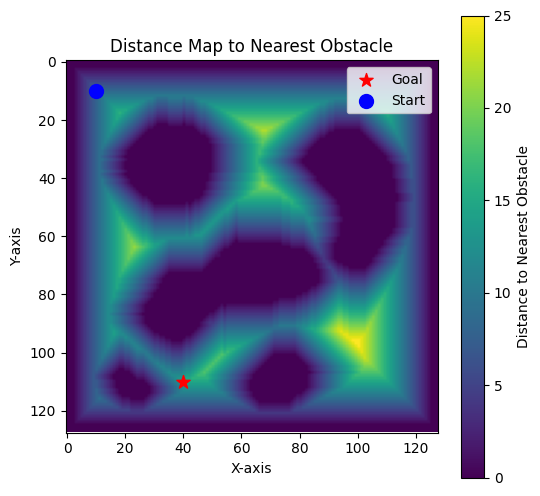

In [98]:
#Repulsive function
#Exercise 2:
from collections import deque
def brushfire_algorithm(grid_map):
    """
    Brushfire algorithm to compute distances from each cell to the nearest obstacle.
    """
    height, width = grid_map.shape
    distance_map = np.full((height, width), np.inf)  # start distance map with infinity
    queue = deque()

    # To Initialize the queue with the obstacle positions
    for y in range(height):
        for x in range(width):
            if grid_map[y, x] == 1:  # If it's an obstacle
                distance_map[y, x] = 0  # Distance to itself is 0
                queue.append((y, x))

    # Directions for neighboring cells (N, S, E, W)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    # Perform BFS to calculate distances
    while queue:
        y, x = queue.popleft()
        current_distance = distance_map[y, x]

        # Check all 4 directions
        for dy, dx in directions:
            ny, nx = y + dy, x + dx
            if 0 <= ny < height and 0 <= nx < width: 
                if distance_map[ny, nx] > current_distance + 1:  
                    distance_map[ny, nx] = current_distance + 1
                    queue.append((ny, nx))

    return distance_map

distance_map = brushfire_algorithm(grid_map)


# To Plot the distance map
plt.figure(figsize=(6, 6))
plt.imshow(distance_map, cmap='viridis', origin='upper')
plt.colorbar(label="Distance to Nearest Obstacle")
plt.scatter(goal_position[1], goal_position[0], color='red', marker='*', s=100, label="Goal")  # goal position mark
plt.scatter(start_position[1], start_position[0], color='blue', marker='o', s=100, label="Start")  # start position mark
plt.title("Distance Map to Nearest Obstacle")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.show()

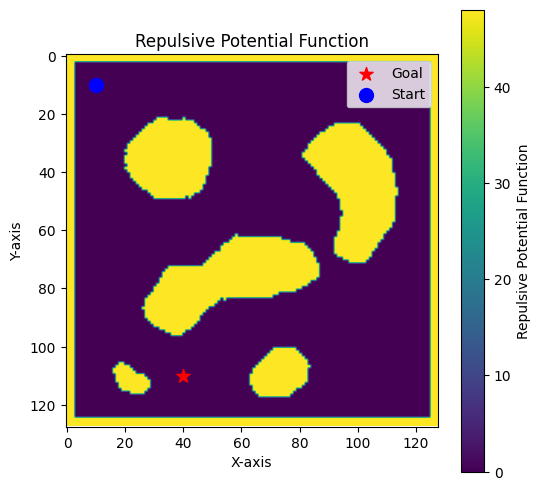

In [99]:
#Exercise 3:
#Implement a function to compute the repulsive function given a map of distances and a Q value.
def compute_repulsive_potential(distance_map, Q, epsilon=1e-1):
    """
    To Compute the repulsive potential field from a distance map.
    """
    # To Initialize the repulsive potential map
    repulsive_potential = np.zeros_like(distance_map)

    # To Compute the repulsive potential based on the distance map
    for y in range(distance_map.shape[0]):
        for x in range(distance_map.shape[1]):
            d = distance_map[y, x]
            if d < Q:
                repulsive_potential[y, x] = 0.5 * (1/(d + epsilon) - 1/Q) ** 2
            else:
                repulsive_potential[y, x] = 0

    return repulsive_potential

Q = 5  # sacling factor for repulsive potential
repulsive_potential = compute_repulsive_potential(distance_map, Q)

# To Plot the repulsive potential function
plt.figure(figsize=(6, 6))
plt.imshow(repulsive_potential, cmap='viridis', origin='upper')
plt.colorbar(label="Repulsive Potential Function")
plt.title("Repulsive Potential Function")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.scatter(goal_position[1], goal_position[0], color='red', marker='*', s=100, label="Goal")
plt.scatter(start_position[1], start_position[0], color='blue', marker='o', s=100, label="Start")
plt.legend()
plt.show()


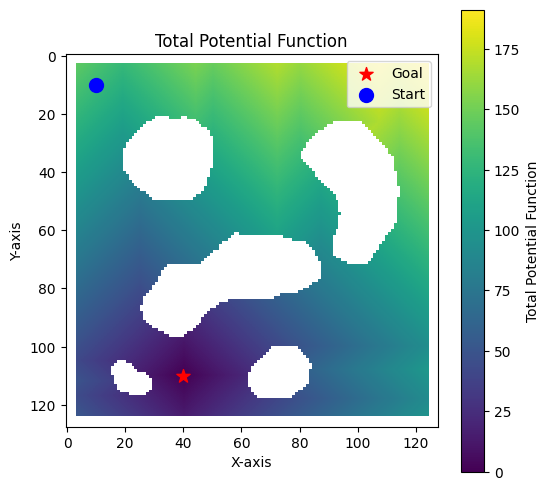

In [104]:
#Total Potential Function: combining the Attraction and Repulsive functions
#Exercise 4:
def compute_total_potential(attraction_potential,repulsive_potential):
    """
    To Compute the total potential function by combining attraction and repulsive potentials.
    """
    # To Initialize the repulsive potential map
    total_potential = attraction_potential + repulsive_potential
    
    return total_potential

total_potential = compute_total_potential(attraction_potential,repulsive_potential)

# To Plot the total potential function
plt.figure(figsize=(6, 6))

plt.imshow(total_potential, cmap='viridis', origin='upper')
plt.colorbar(label="Total Potential Function")
plt.title("Total Potential Function")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.scatter(goal_position[1], goal_position[0], color='red', marker='*', s=100, label="Goal")
plt.scatter(start_position[1], start_position[0], color='blue', marker='o', s=100, label="Start")
plt.legend()
plt.show()


Goal reached!


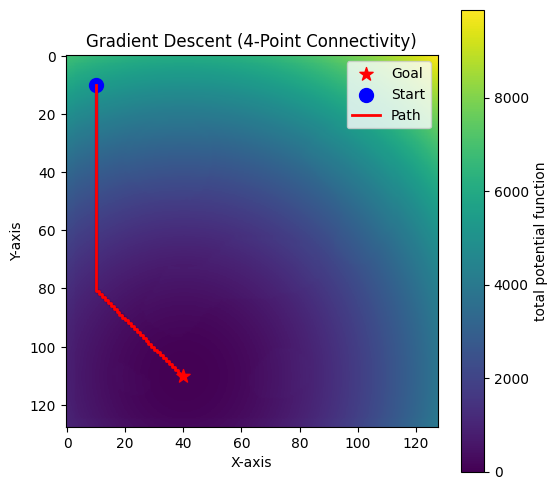

In [101]:
#Part 2
#Gradient Descent
def gradient_descent_4connectivity(total_potential, start, goal, max_steps=10000, tolerance=1e-4):
    """
    To Compute the path from start to goal using gradient descent on the total potential field
    with 4-point connectivity (up, down, left, right).
    """
    # To Initialize the path with the start position
    path = [start]
    current_position = start

    #4-point connectivity directions (up, down, left, right)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    # Gradient descent with 4-point connectivity
    for _ in range(max_steps):
        y, x = current_position

        # if close enough to the goal
        if np.linalg.norm(np.array([y, x]) - np.array(goal)) < tolerance:
            print("Goal reached!")
            break

        # Neighbors cells in the 4-point connectivity
        neighbors = [(y + dy, x + dx) for dy, dx in directions]
        valid_neighbors = [(ny, nx) for ny, nx in neighbors if 0 <= ny < total_potential.shape[0] and 0 <= nx < total_potential.shape[1]]
        
        # Neighbor cell with the lowest potential value
        next_position = min(valid_neighbors, key=lambda pos: total_potential[pos[0], pos[1]])
        
        # If no lower potential, terminate
        if total_potential[next_position[0], next_position[1]] >= total_potential[y, x]:
            print("Reached local minimum, stopping search.")
            break

        # Move to the next cell
        current_position = next_position
        path.append(current_position)

        # Check for goal position within tolerance
        if current_position == goal:
            print("Goal reached!")
            break

    # To Plot  path on the grid map
    grid_map_with_path = np.copy(total_potential)
    for (y, x) in path:
        grid_map_with_path[y, x] = -1  # Mark path cells with a distinctive value for visualization

    return path, grid_map_with_path


# To Compute path using gradient descent with 4-point connectivity
path, grid_map_with_path = gradient_descent_4connectivity(total_potential, start_position, goal_position)

# To Plot total potential with the path
plt.figure(figsize=(6, 6))
plt.imshow(grid_map_with_path, cmap='viridis', origin='upper')
plt.colorbar(label="total potential function")
plt.title("Gradient Descent (4-Point Connectivity)")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.scatter(goal_position[1], goal_position[0], color='red', marker='*', s=100, label="Goal")
plt.scatter(start_position[1], start_position[0], color='blue', marker='o', s=100, label="Start")
plt.plot([x for y, x in path], [y for y, x in path], color='red', linewidth=2, label="Path")
plt.legend()
plt.show()


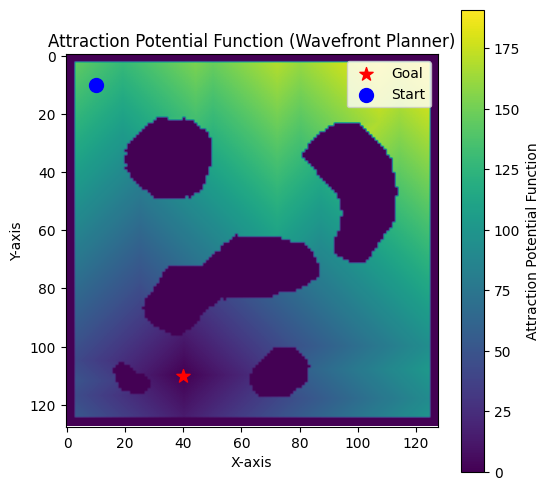

In [102]:
#Part 3
#Wave-front planner
#Exercise 6:
def wave_front_planner(grid_map, start_position, goal_position):
    """
    To Compute the attraction potential field using a wavefront planner.
    """
    # To Initialize attraction potential field with high values
    rows, cols = grid_map.shape
    attraction_potential = np.full((rows, cols), np.inf)  # Starting with infinity
    attraction_potential[goal_position] = 0  # Setting the goal position to 0
    attraction_potential[grid_map == 1] = 0  # Setting potential for obstacles to 0

    # Queue for BFS
    queue = deque([goal_position])

    # Define the 4 connectivity directions (up, down, left, right)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    # Perform wavefront propagation
    while queue:
        current = queue.popleft()
        current_y, current_x = current

        # Process neighbors
        for dy, dx in directions:
            neighbor_y, neighbor_x = current_y + dy, current_x + dx
            
            # Check if the neighbor is within bounds and not an obstacle
            if 0 <= neighbor_y < rows and 0 <= neighbor_x < cols and grid_map[neighbor_y, neighbor_x] == 0:
                # Calculate potential value based on distance from current position
                new_potential = attraction_potential[current_y, current_x] + 1
                if new_potential < attraction_potential[neighbor_y, neighbor_x]:
                    attraction_potential[neighbor_y, neighbor_x] = new_potential
                    queue.append((neighbor_y, neighbor_x))  # Add the neighbor to the queue

    return attraction_potential

# Loading grid map
image = Image.open('map0.png').convert('L')
grid_map = np.array(image.getdata()).reshape(image.size[0], image.size[1]) / 255
# Binarize the image
grid_map[grid_map > 0.5] = 1
grid_map[grid_map <= 0.5] = 0
# Invert colors to make 0 -> free and 1 -> occupied
grid_map = (grid_map * -1) + 1

# Define start and goal positions
start_position = (10, 10)  # Start position (y, x)
goal_position = (110, 40)  # Goal position (y, x)

# Compute the attraction potential using wavefront planning
attraction_potential = wave_front_planner(grid_map, start_position, goal_position)

# Plot the attraction potential function
plt.figure(figsize=(6, 6))
plt.imshow(attraction_potential, cmap='viridis', origin='upper')
plt.colorbar(label="Attraction Potential Function")
plt.title("Attraction Potential Function (Wavefront Planner)")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.scatter(goal_position[1], goal_position[0], color='red', marker='*', s=100, label="Goal")
plt.scatter(start_position[1], start_position[0], color='blue', marker='o', s=100, label="Start")
plt.legend()
plt.show()


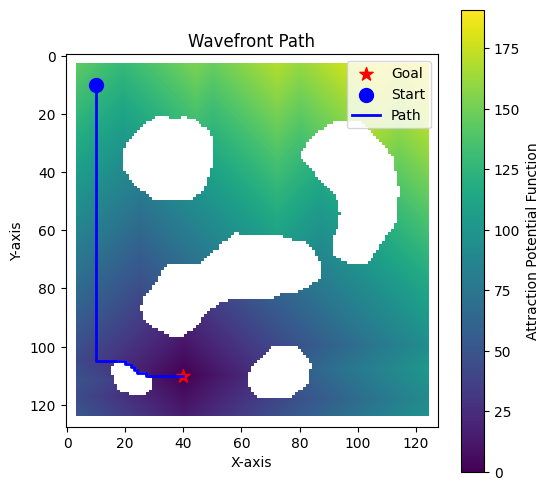

In [103]:
#Finding the path
#Exercise 7:
def wave_front_planner(grid_map, goal_position):
    """
    To Compute the attraction potential field using a wavefront planner.
    """
    # To Initialize the attraction potential field with high values
    rows, cols = grid_map.shape
    attraction_potential = np.full((rows, cols), np.inf)  # Start with infinity
    attraction_potential[goal_position] = 0  # Set the goal position to 0
    attraction_potential[grid_map == 1] = np.inf  # Set potential for obstacles to infinity

    # Queue for BFS
    queue = deque([goal_position])

    # Define the 4 connectivity directions (up, down, left, right)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    # Perform wavefront propagation
    while queue:
        current = queue.popleft()
        current_y, current_x = current

        # Process neighbors
        for dy, dx in directions:
            neighbor_y, neighbor_x = current_y + dy, current_x + dx
            
            # Check if the neighbor is within bounds and not an obstacle
            if 0 <= neighbor_y < rows and 0 <= neighbor_x < cols and grid_map[neighbor_y, neighbor_x] == 0:
                # Calculate potential value based on distance from current position
                new_potential = attraction_potential[current_y, current_x] + 1
                if new_potential < attraction_potential[neighbor_y, neighbor_x]:
                    attraction_potential[neighbor_y, neighbor_x] = new_potential
                    queue.append((neighbor_y, neighbor_x))  # Add the neighbor to the queue

    return attraction_potential

def find_path(attraction_potential, start_position):
    """
    Finding a path from start to goal using the attraction potential map by following the gradient descent.
    """
    path = [start_position]
    current_pos = start_position

    while attraction_potential[current_pos] != 0:  # Continue until reaching the goal (potential 0)
        y, x = current_pos
        # Get the values of the neighboring cells
        neighbors = [
            ((y - 1, x), attraction_potential[y - 1, x]) if y > 0 else (None, np.inf),
            ((y + 1, x), attraction_potential[y + 1, x]) if y < attraction_potential.shape[0] - 1 else (None, np.inf),
            ((y, x - 1), attraction_potential[y, x - 1]) if x > 0 else (None, np.inf),
            ((y, x + 1), attraction_potential[y, x + 1]) if x < attraction_potential.shape[1] - 1 else (None, np.inf)
        ]
        
        # Choose the neighbor with the smallest potential value
        next_pos = min(neighbors, key=lambda n: n[1])[0]
        
        # Check for local minimum or no path found
        if next_pos is None or next_pos in path:
            print("No valid path found. Path is stuck or reached a local minimum.")
            break
        
        path.append(next_pos)
        current_pos = next_pos

    return path


# Define start and goal positions
start_position = (10, 10)  # Start position (y, x)
goal_position = (110, 40)  # Goal position (y, x)

# Compute the attraction potential using wavefront planning
attraction_potential = wave_front_planner(grid_map, goal_position)

# Find the path from start to goal
path = find_path(attraction_potential, start_position)

# Plotting the attraction potential function and the path
plt.figure(figsize=(6, 6))
plt.imshow(attraction_potential, cmap='viridis', origin='upper')
plt.colorbar(label="Attraction Potential Function")
plt.title("Wavefront Path")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.scatter(goal_position[1], goal_position[0], color='red', marker='*', s=100, label="Goal")
plt.scatter(start_position[1], start_position[0], color='blue', marker='o', s=100, label="Start")

# Ploting the path
if path:
    path_y, path_x = zip(*path)
    plt.plot(path_x, path_y, color="blue", linewidth=2, label="Path")
plt.legend()
plt.show()
